# Part 1 - Exploratory data analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading into a DataFrame and preprocessing by adding 'count' so that each login is counted as an instance
df = pd.read_json('ultimate_challenge/logins.json')
df['count'] = 1
df.head()

,login_time,count
0,1970-01-01 20:13:18,1
1,1970-01-01 20:16:10,1
2,1970-01-01 20:16:37,1
3,1970-01-01 20:16:36,1
4,1970-01-01 20:26:21,1


In [2]:
df.tail()

,login_time,count
93137,1970-04-13 18:50:19,1
93138,1970-04-13 18:43:56,1
93139,1970-04-13 18:54:02,1
93140,1970-04-13 18:57:38,1
93141,1970-04-13 18:54:23,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
 1   count       93142 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.4 MB


There is no missing data and there are no apparent integrity issues or errors but we note that the final month, April 1970, is incomplete.

Indexing by datetime and aggregating to 15-minute intervals:

In [4]:
df = df.set_index('login_time').sort_index()

# Aggregate to 15-minute intervals
df_15 = df.resample('15min').sum()

Visualizations:

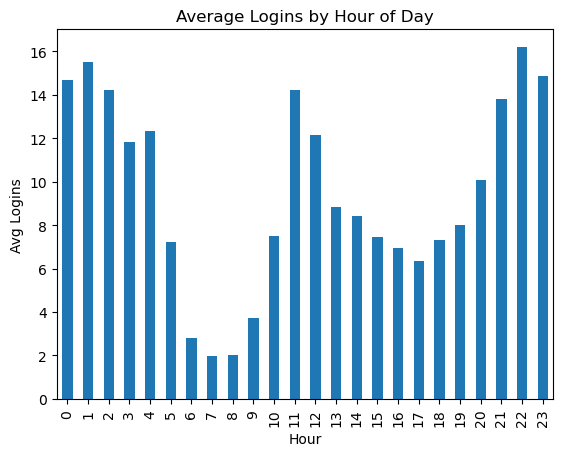

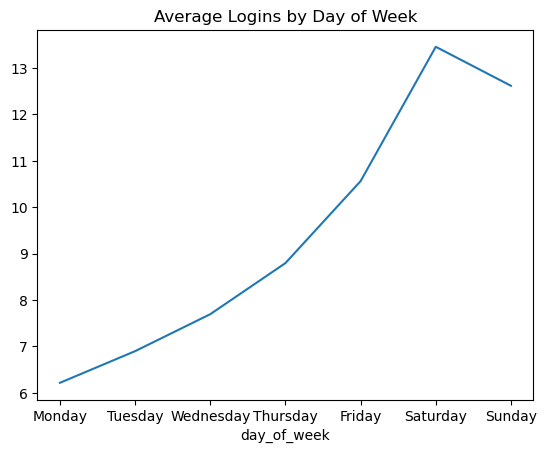

In [5]:
# Visualization: Daily Cycles (Aggregated by hour)
df_15['hour'] = df_15.index.hour
df_15.groupby('hour')['count'].mean().plot(kind='bar')
plt.title('Average Logins by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Logins')
plt.show()

# Visualization: Weekly Patterns
df_15['day_of_week'] = df_15.index.day_name()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_15.groupby('day_of_week')['count'].mean().reindex(days).plot(kind='line')
plt.title('Average Logins by Day of Week')
plt.show()

We can see from these graphs that logins peak approximately from 11am until 1pm and from 10pm until 2am and that there is more activity on the weekend days than on weekdays, with the highest average logins on Saturday.

# Part 2 - Experiment and metrics design

1) I would choose the ratio of inter-city trips to total trips per driver. This would be a good metric because it basically adjusts for the total driving volume and other preferences of each driver and avoids the confounding factors that could influence the total logins and total revenue (for each or both cities), such as holidays, changing demographics, and major local events. It is also easy to test in A/B testing to determine the effect of the toll reimbursements on driver behavior.

2) To test the effectiveness of the proposed change, I would recommend a randomized, controlled trial (i.e. an A/B Test). 
    * Implementation: Randomly assign current active drivers into two groups: Group A (a control group) continues paying tolls as usual; Group B receives the toll reimbursements. Record login data for at least a month to capture four full weekly cycles (weekdays vs. weekends). Measure our metric (inner-city trips/total trips) per driver over the duration of the experiment. 

    * Statistical Testing: I would use a two-way z-test to compare the means of the metric between the two groups. We would expect the metric to increase once the toll reimbursements are introduced, so we take as the null hypothesis:
  
      Null Hypothesis (H_0): There is no difference in the mean ratio of inter-city trips to total trips between the two groups A and B.

    * Interpretation & Recommendations: If p < 0.05: We can reject the null hypothesis and conclude that reimbursement significantly increased inter-city mobility as desired. I would recommend a long-term rollout, provided the increased revenue from the extra trips exceeds the cost of reimbursements. The setup should be observed for a longer time to determine if there are any unexpected negative effects on user experience before it is made permanent.

# Part 3 - Predictive modeling

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

After converting *sign-up date* and *last-trip-date* to datetime format, we fill missing driver rating values using simple imputer (the mean) and fill missing *phone* records with "Other". There appear to be no duplicates or obvious errors.

Retained users tend to have higher *trips_in_first_30_days* and lower *avg_dist*, higher *surge_pct* and are more likely to be an *ultimate_black_user*.

King's Landing has the highest retention and Astapor city has the lowest.

Fraction retained: 0.37608
retained
0    31196
1    18804
Name: ultimate_black_user, dtype: int64


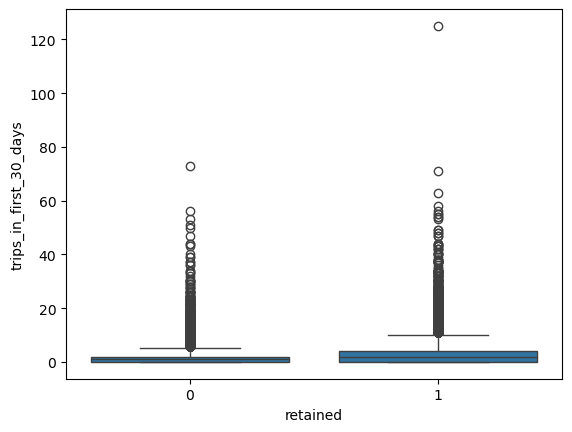

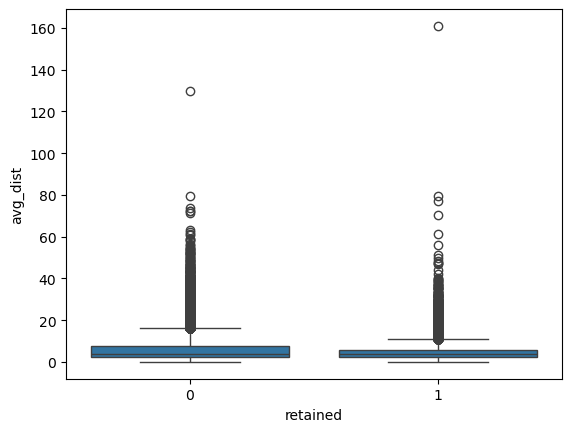

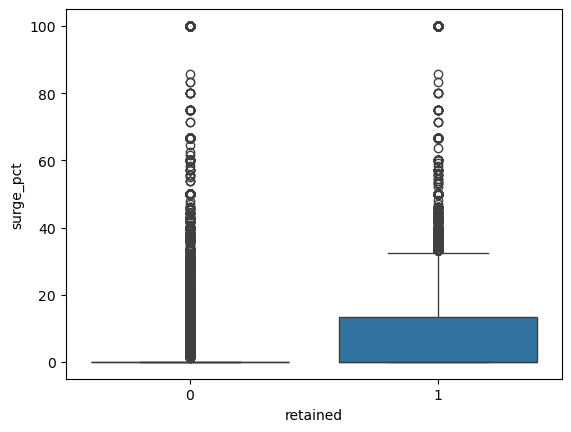

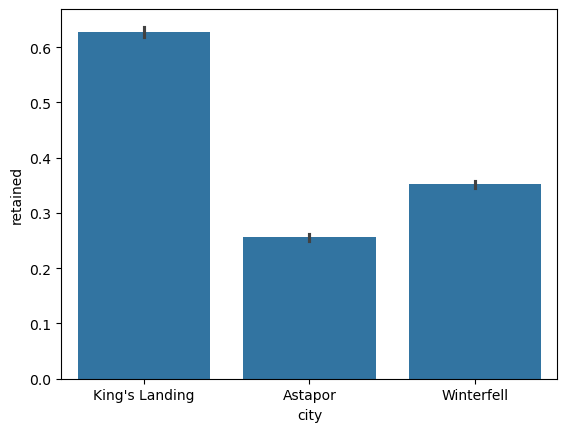

In [7]:
# Load data
df = pd.read_json('ultimate_challenge/ultimate_data_challenge.json')

# Cleaning
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])
imputer = SimpleImputer(strategy='mean')
df[['avg_rating_by_driver', 'avg_rating_of_driver']] = imputer.fit_transform(df[['avg_rating_by_driver', 'avg_rating_of_driver']])
df['phone'] = df['phone'].fillna('Other')

# Define retained
df['retained'] = (df['last_trip_date'] >= '2014-06-01').astype(int)
print('Fraction retained:', df['retained'].mean())  # 0.37608

print(df['ultimate_black_user'].groupby(df.retained).count())

# EDA plots
sns.boxplot(x='retained', y='trips_in_first_30_days', data=df)
plt.show()

sns.boxplot(x='retained', y='avg_dist', data=df)
plt.show()

sns.boxplot(x='retained', y='surge_pct', data=df)
plt.show()

sns.barplot(x='city', y='retained', data=df)
plt.show()

I chose to use a Random Forest Classifier for its robustness to mixed data types, handling of non-linearity, and built-in feature importance. Alternatives considered: Logistic Regression (simpler model but assumes linearity); Gradient Boosting (more accurate but can be prone to overfitting and is slower). 

Concerns: There is a class imbalance (37% positive) in the data but this can be mitigated with class weights.

The model was trained on 80/20 split with one-hot encoding for the city and phone. 

Validity: Cross-validated **AUC 0.76**, accuracy **0.75**, precision **0.72**, recall **0.58 (F1 0.64)**. 

This is not bad but the recall is low, showing that the model is better at identifying non-retained users. 

In [8]:
# Preparing data features
features = ['city', 'phone', 'avg_dist', 'avg_rating_by_driver', 'avg_rating_of_driver', 
            'surge_pct', 'avg_surge', 'trips_in_first_30_days', 'ultimate_black_user', 'weekday_pct']
X = df[features]
y = df['retained']

# Preprocessing
categorical = ['city', 'phone']
preprocessor = ColumnTransformer([('onehot', OneHotEncoder(), categorical)], remainder='passthrough')
X = preprocessor.fit_transform(X)

# Train/test split and model fitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Performance eval
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Cross-validation
cv_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
print('CV AUC:', cv_auc)

# Feature importance (adjust indices for one-hot)
importances = pd.Series(model.feature_importances_, index=preprocessor.get_feature_names_out()).sort_values(ascending=False)
print(importances)

Accuracy: 0.7501
AUC: 0.7303417970855625
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      6219
           1       0.68      0.65      0.66      3781

    accuracy                           0.75     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.75      0.75      0.75     10000

CV AUC: 0.820759833323252
remainder__avg_dist                  0.305456
remainder__weekday_pct               0.131896
remainder__avg_rating_by_driver      0.115410
remainder__trips_in_first_30_days    0.081900
remainder__avg_rating_of_driver      0.080588
remainder__surge_pct                 0.075115
remainder__avg_surge                 0.063314
onehot__city_King's Landing          0.045606
remainder__ultimate_black_user       0.030001
onehot__phone_iPhone                 0.020344
onehot__phone_Android                0.018879
onehot__city_Astapor                 0.018062
onehot__city_Winterfell              0.012245
onehot__

To leverage the insights gained from this model, Ultimate can target low-engagement users (e.g., less than a given number of trips in first 30 days) with promotions like free surges or black car trials to boost early activity. The company could focus its marketing in known high-retention cities like King's Landing and improve Android app usability to close the retention gap with iPhone users. It would also make sense to try to analyze why short-trip users seem to be retained more than longer-trip users.